In [1]:
#importing the nescassary libraries for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset
#source link: "https://www.kaggle.com/datasets/shivamb/netflix-shows"
df = pd.read_csv('netflix_titles.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
#statistical data
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


df.columns

In [5]:
#displaying the first 10 rows of the dataset, we can clearly see some missing values
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [6]:
#checking for missing values values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
#Cleaning the dataset by dealing with the missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [8]:
#verifying that there are no more missing data
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [9]:
#Checking for the unique values
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [10]:
#creating a new df where it only contains movies
movies_df = df[df['type'] == 'Movie']

In [11]:
#getting the top 10 countries from that dataframe
top_10_countries_movies = movies_df['country'].value_counts().head(10)

# Q1: who are the top 10 movie producing countries?

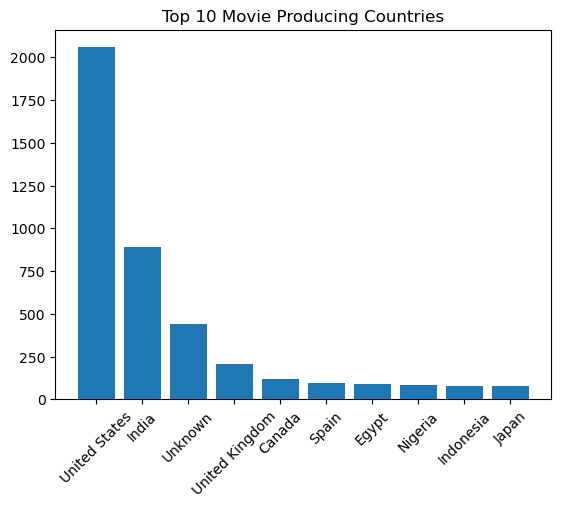

In [12]:
#plotting the top 10 movie producing countries on a barchart
x = top_10_countries_movies.index 
y = top_10_countries_movies.values
plt.bar(x, y)
plt.title('Top 10 Movie Producing Countries')
plt.xticks(rotation=45)
plt.show()

In [13]:
#doing the same for tv shows (creating a df with only tv shows)
tv_shows_df = df[df['type'] == 'TV Show']

In [14]:
#getting the top 10 tv shows producing countries
top_10_countries_tv_shows = tv_shows_df['country'].value_counts().head(10)

# Q2: Who are the top 10 TV shows producing countries?

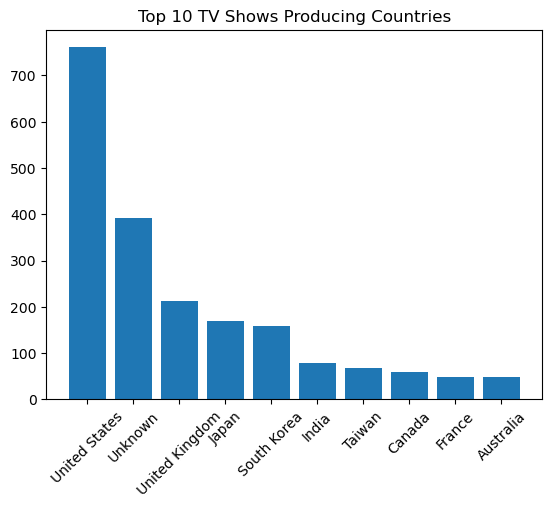

In [15]:
#plotting the top 10 tv shows producing countries on a barchart
x = top_10_countries_tv_shows.index 
y = top_10_countries_tv_shows.values
plt.bar(x, y)
plt.title('Top 10 TV Shows Producing Countries')
plt.xticks(rotation=45)
plt.show()

In [16]:
#getting the unique values int he tv shows df
tv_shows_df['duration'].unique()

<StringArray>
[ '2 Seasons',   '1 Season',  '9 Seasons',  '4 Seasons',  '5 Seasons',
  '3 Seasons',  '6 Seasons',  '7 Seasons', '10 Seasons',  '8 Seasons',
 '17 Seasons', '13 Seasons', '15 Seasons', '12 Seasons', '11 Seasons']
Length: 15, dtype: str

# Q3: how are the tv shows durations distributed

<Axes: title={'center': 'TV Shows Durations Distribution'}, ylabel='Frequency'>

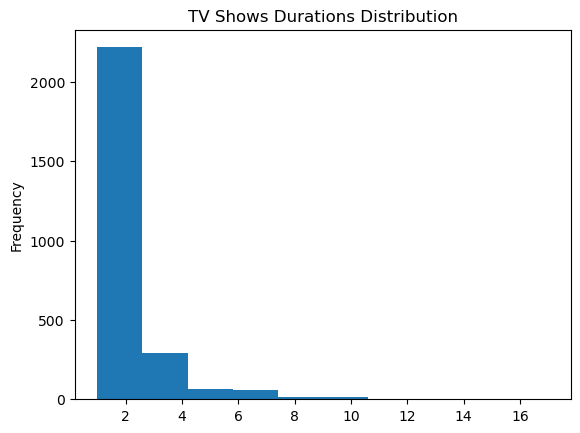

In [17]:
#type casting the ['duration'] in tv shows df to float in order to plot it on a histogram
tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float).plot(kind="hist", title='TV Shows Durations Distribution')

In [18]:
#getting the unique durations in movies df
movies_df['duration'].unique()

<StringArray>
[ '90 min',  '91 min', '125 min', '104 min', '127 min',  '67 min',  '94 min',
 '161 min',  '61 min', '166 min',
 ...
  '43 min', '200 min', '196 min', '167 min', '178 min', '228 min',  '18 min',
 '205 min', '201 min', '191 min']
Length: 206, dtype: str

# Q4: how are the Movies durations distributed

<Axes: title={'center': 'Movies Durations Distribution'}, ylabel='Frequency'>

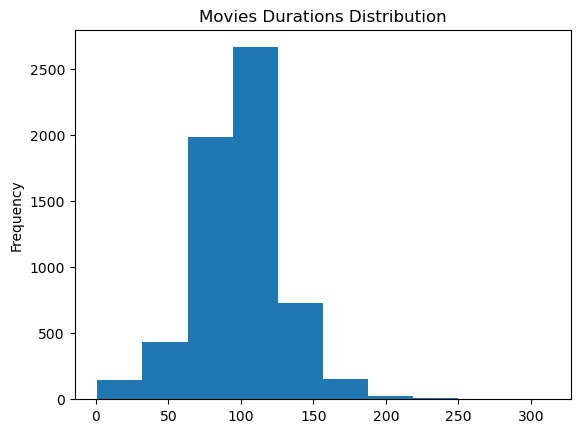

In [19]:
#typecasting the ['duration'] to float and plotting it on a histogram
movies_df['duration'].str.replace(' min', '').str.replace(' Season', '').astype(float).plot(kind='hist', title='Movies Durations Distribution')

# Q5: How is the distribution of Movies vs TV shows?

C:\Users\ahmed\AppData\Local\Temp\ipykernel_17180\847076418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


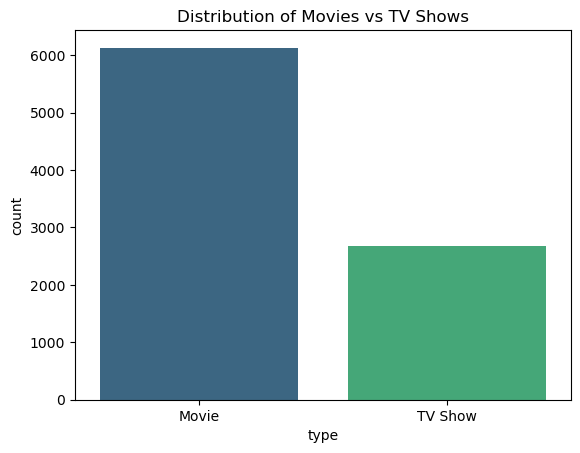

In [20]:
#number of movies vs tv shows
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Movies vs TV Shows')
plt.show()

# Q6: Is content added year by year inc. or dec.?
# Q7: How did the Corona virus pandemic affect the movies and tv shows industry?

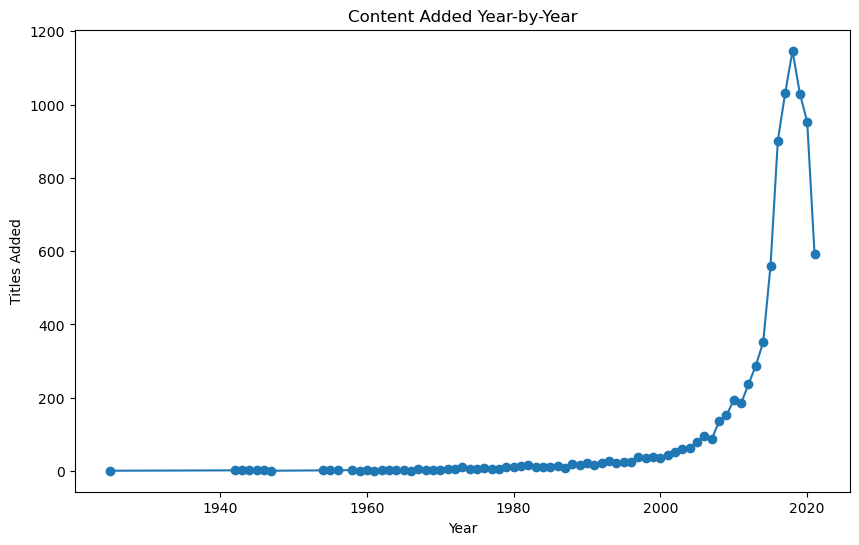

In [21]:
# Content added year-by-year, we can notice the movies and tv shows industry really take off by the year 2010
# We cam also see it dipping down alot by the year 2020 possibly due to the Corona viruse pandemic
plt.figure(figsize=(10,6))
df['release_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Content Added Year-by-Year')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.show()

# Q8: Top countries for Kids' content

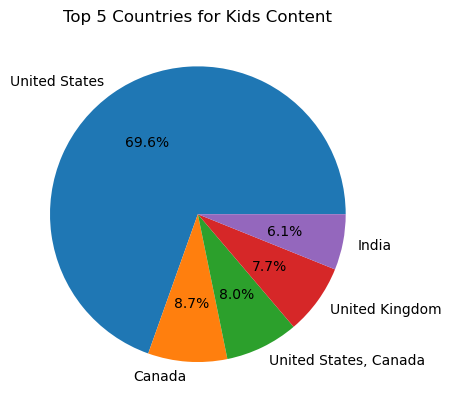

In [22]:
kids_content = df[df['rating'].isin(['TV-Y', 'TV-Y7', 'G'])]
# Filter out "Unknown" countries and get value counts of remaining countries
kids_content[kids_content['country'] != "Unknown"]['country'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Countries for Kids Content')
plt.ylabel('')
plt.show()

# Q9: Most productive directors

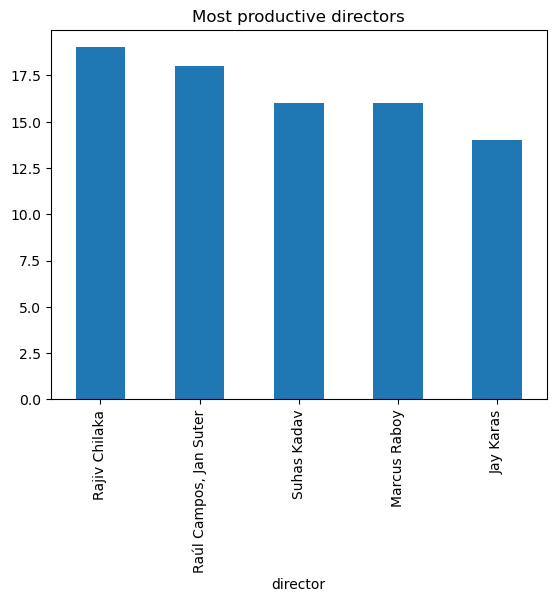

In [23]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head()
top_directors.plot(kind='bar')
plt.title('Most productive directors')
plt.show()

# Q10: What are the top 10 genres?

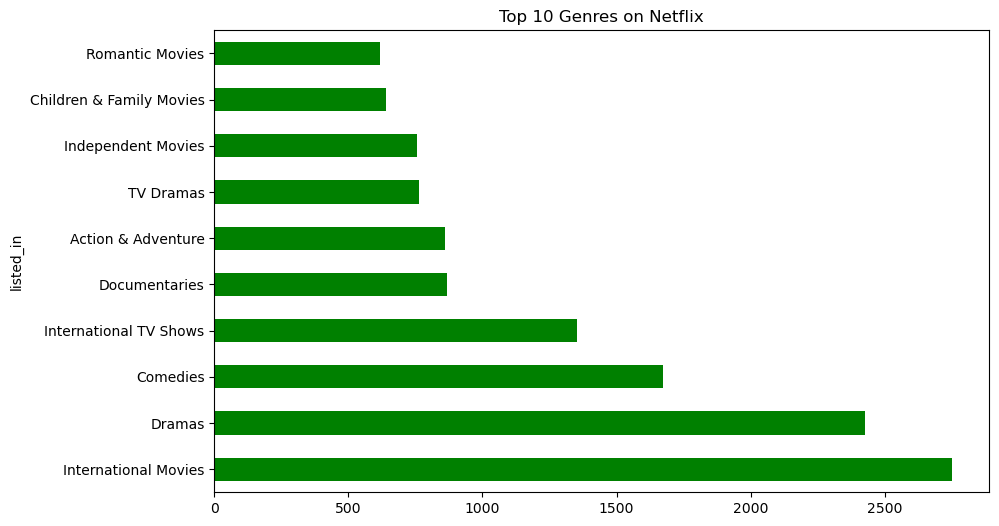

In [24]:
genres = df['listed_in'].str.split(', ').explode()
plt.figure(figsize=(10,6))
genres.value_counts().head(10).plot(kind='barh', color='green')
plt.title('Top 10 Genres on Netflix')
plt.show()

# Q11: Content added by month?

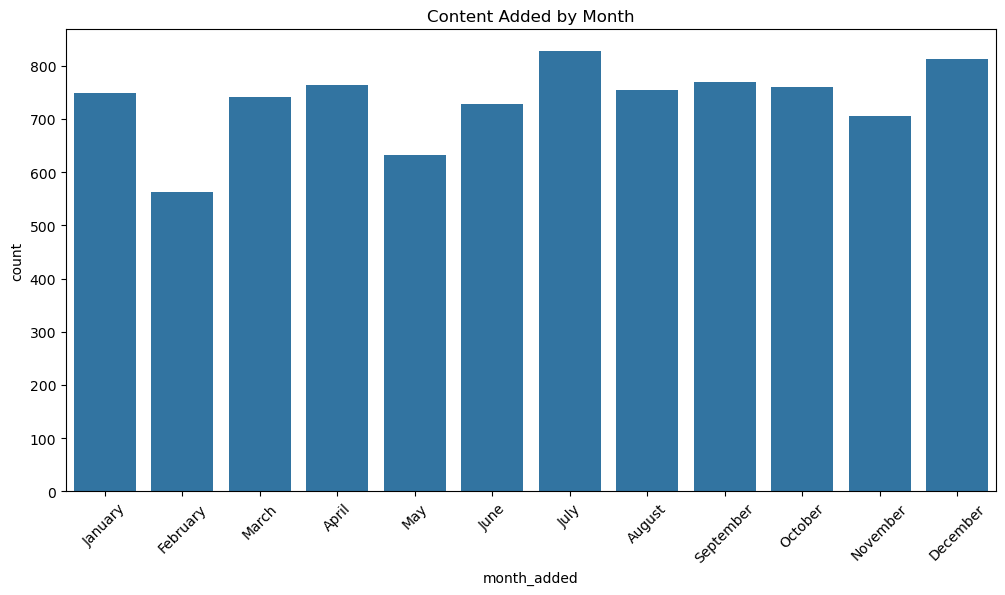

In [25]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['month_added'] = df['date_added'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12,6))
sns.countplot(x='month_added', data=df, order=month_order)
plt.title('Content Added by Month')
plt.xticks(rotation=45)
plt.show()

# Q12: How is the content Ratings Distribution?

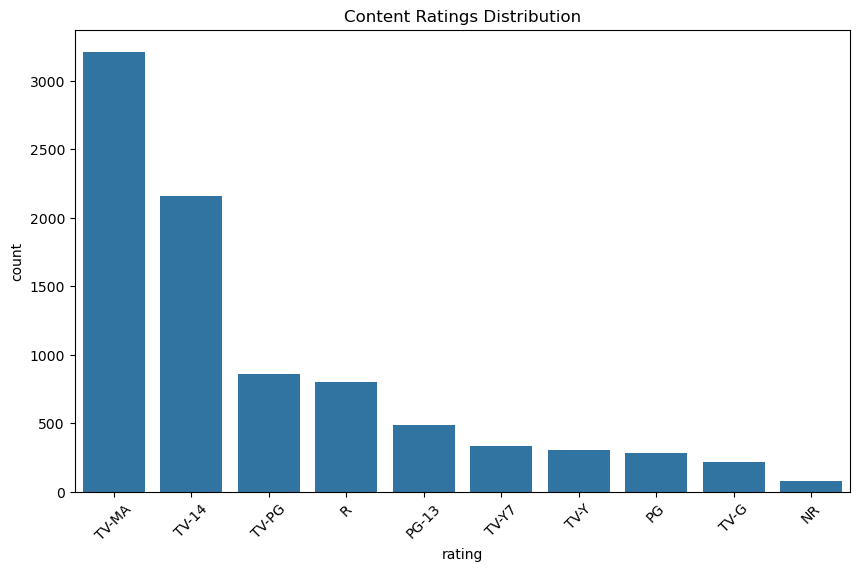

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().head(10).index)
plt.title('Content Ratings Distribution')
plt.xticks(rotation=45)
plt.show()

# Q13: distribution of Egyptian content?

Number of Egyptian titles: 117


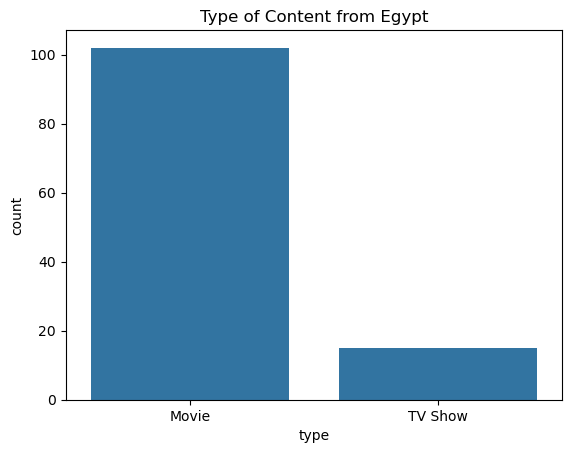

In [27]:
egypt_content = df[df['country'].str.contains('Egypt', na=False)]
print(f"Number of Egyptian titles: {len(egypt_content)}")

# Show the split for Egypt
sns.countplot(x='type', data=egypt_content)
plt.title('Type of Content from Egypt')
plt.show()

# Q14: What are the top genres in Egypt?

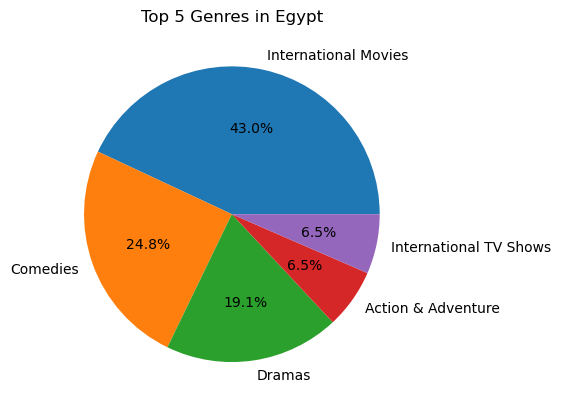

In [28]:
egy_genres = egypt_content['listed_in'].str.split(', ').explode()
egy_genres.value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Genres in Egypt')
plt.ylabel('')
plt.show()

# Q15: who are the top 10 actors in Egypt?

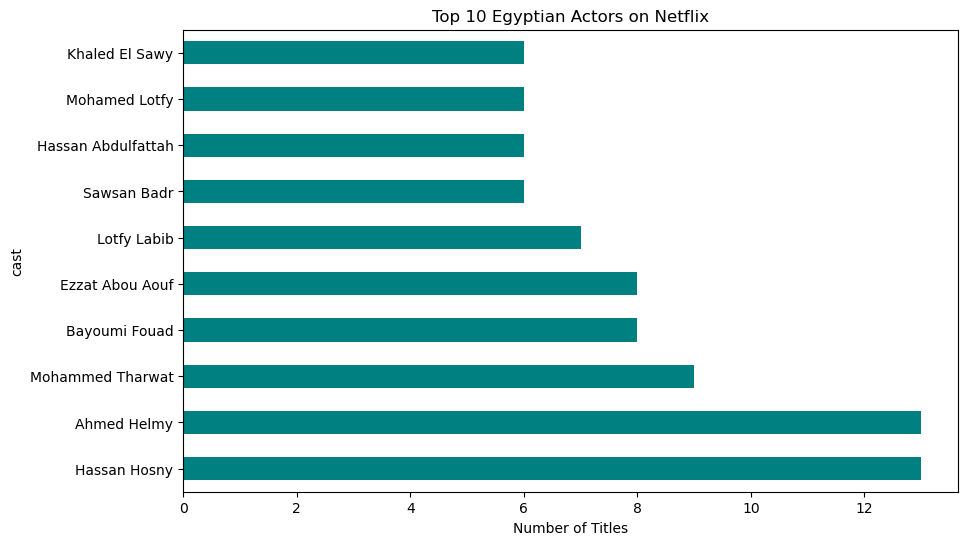

In [29]:
# Filter for Egyptian content
egyptian_titles = df[df['country'].str.contains('Egypt', na=False)]

# Split and count the cast members
egy_cast = egyptian_titles['cast'].str.split(', ').explode()
egy_cast = egy_cast[egy_cast != 'Unknown'] # Exclude Unknown

plt.figure(figsize=(10,6))
egy_cast.value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Egyptian Actors on Netflix')
plt.xlabel('Number of Titles')
plt.show()